# Дипломный проект - Неделя 1

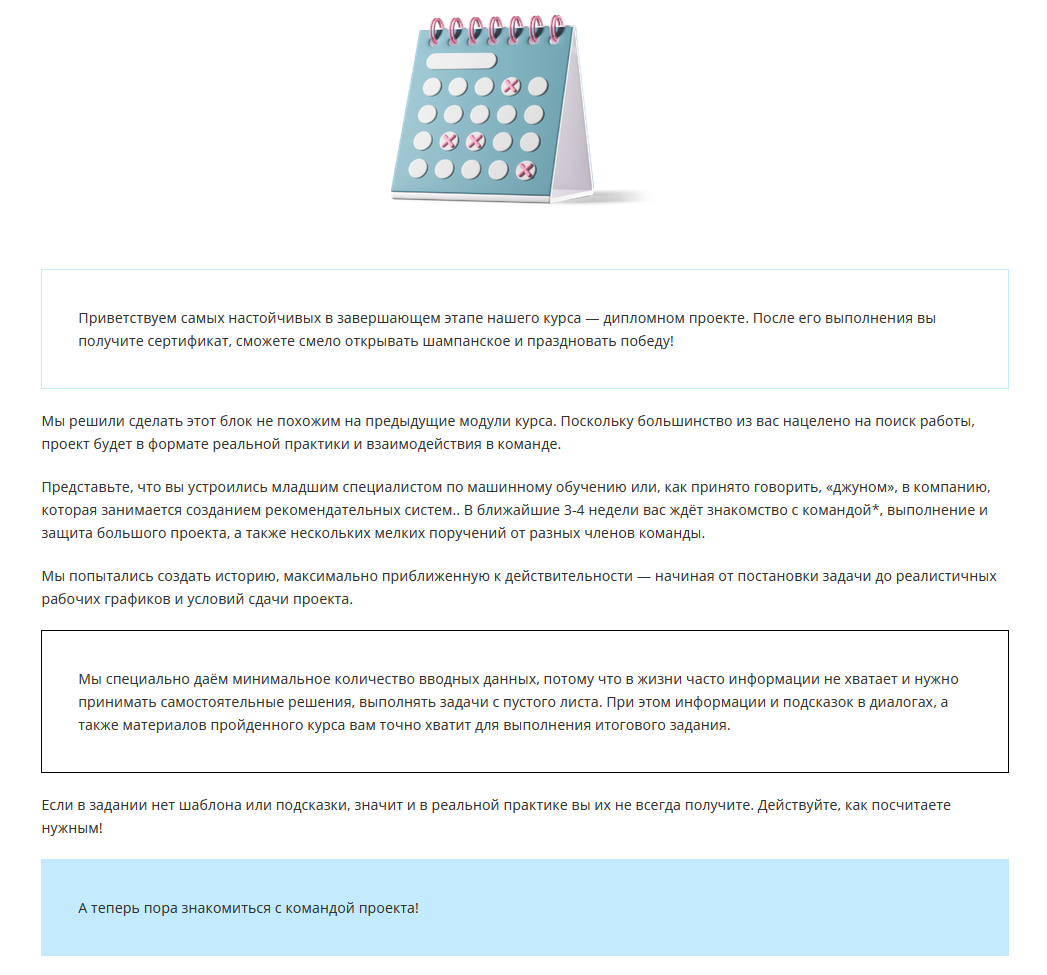

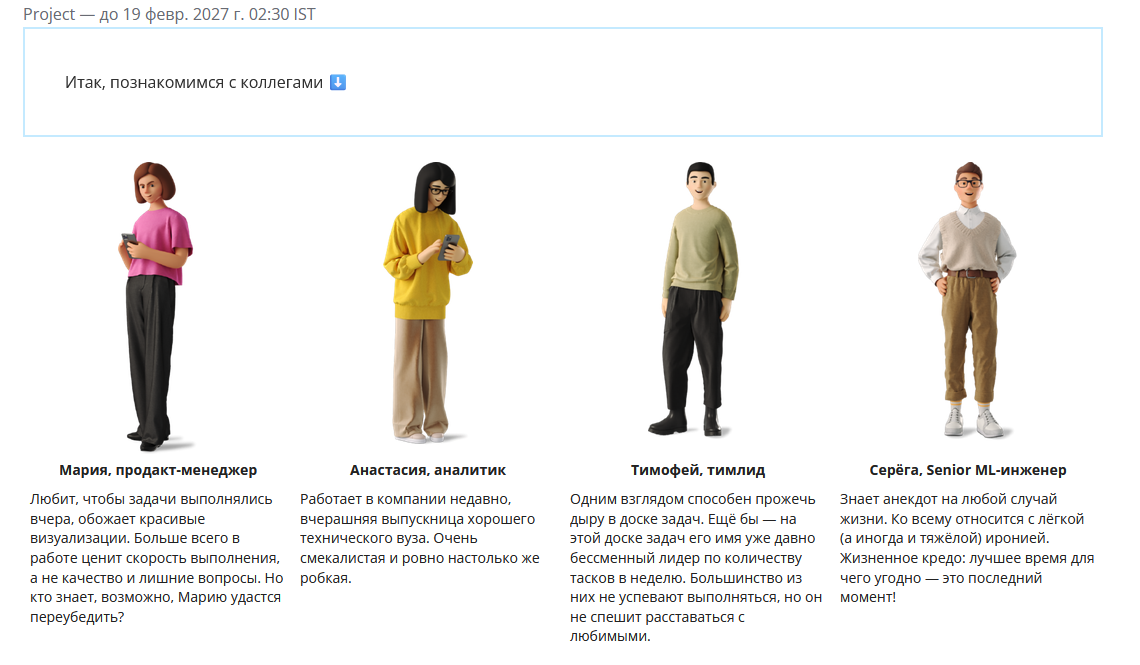

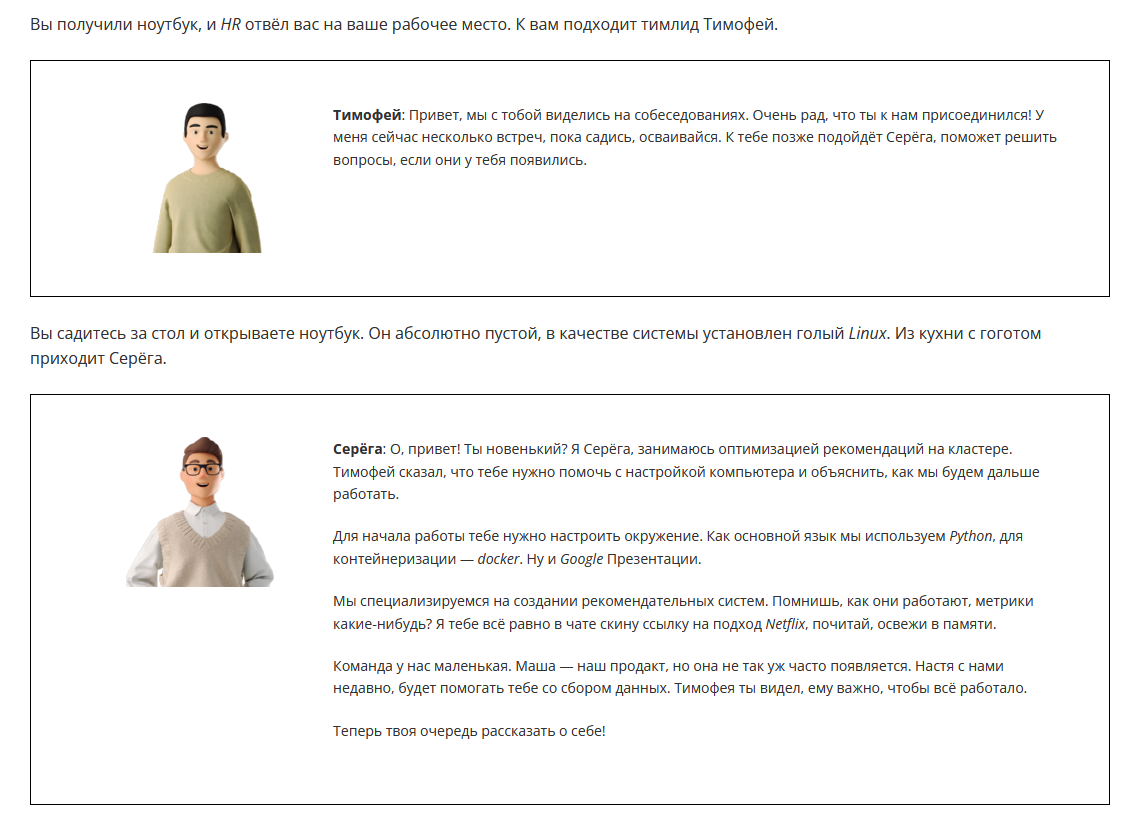

Серёга: Класс! Ну ладно, обживайся :) Попозже к тебе ещё Тимофей обратится, расскажет, как тут что. Ой, кстати, и вот ссылка про подход Netflix, я тебе обещал.

https://medium.com/data-science/deep-dive-into-netflixs-recommender-system-341806ae3b48

# 2. Постановка задачи на проект и EDA

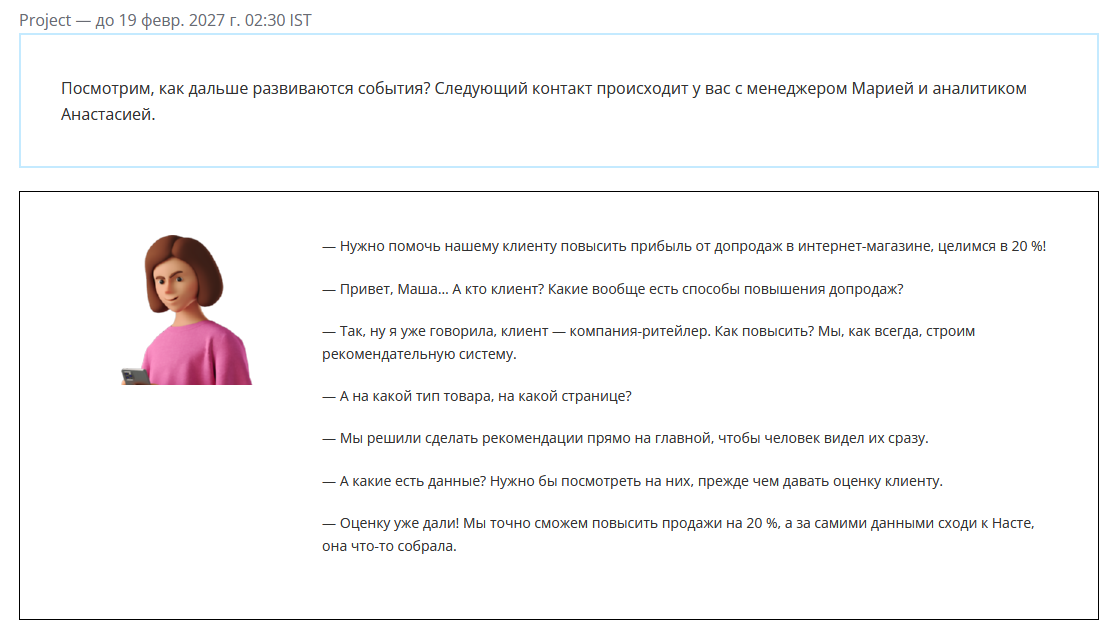

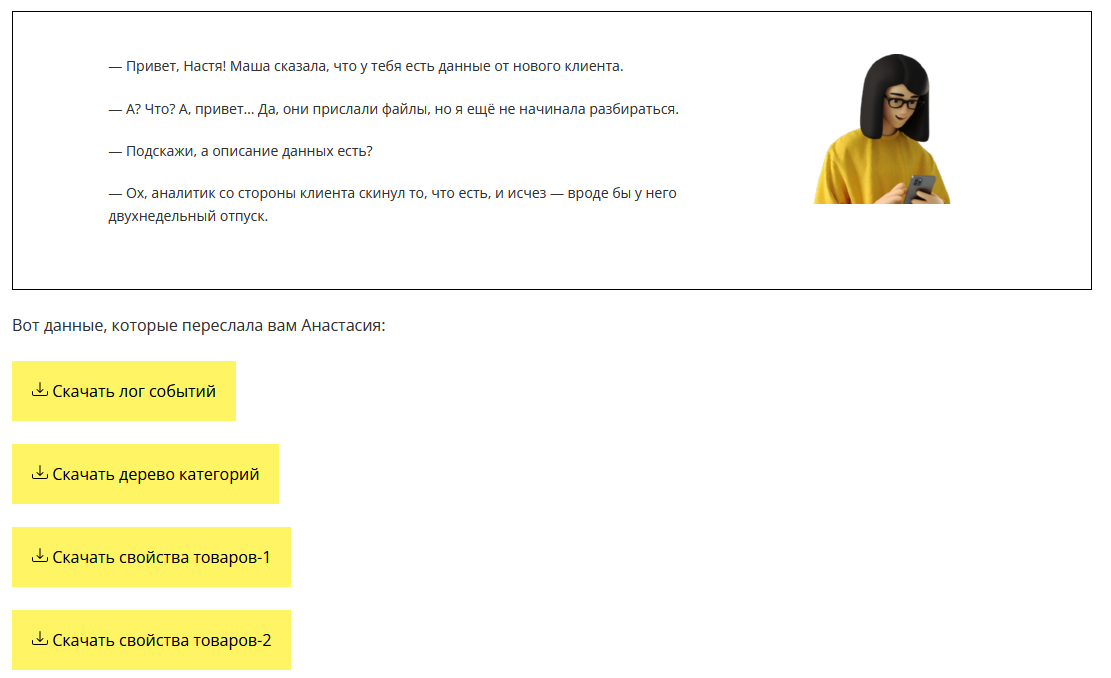

### Импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Проверим и подгрузим **Events Log**

In [2]:
events_log = pd.read_csv('data_import/events.csv')
display(events_log.head(3))
display(events_log.info())
display(events_log.describe())
display(events_log.isna().sum())

print('Total Duplicates detected: {}'.format(events_log[events_log.duplicated()].shape[0]))
# Delete duplicates:
events_log = events_log.drop_duplicates()
print('Table size after delete duplicates: {}'.format(events_log.shape))

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Total Duplicates detected: 460
Table size after delete duplicates: (2755641, 5)


### EDA

Размер датасета: 2,755,641 строк, 5 исходных признака
Период: 2015-05-03 — 2015-09-18
Уникальные пользователи: 1,407,580
Уникальные товары: 235,061
Пропуски transactionid: 99.2%

Распределение событий:


,count
event,
view,2664218
addtocart,68966
transaction,22457


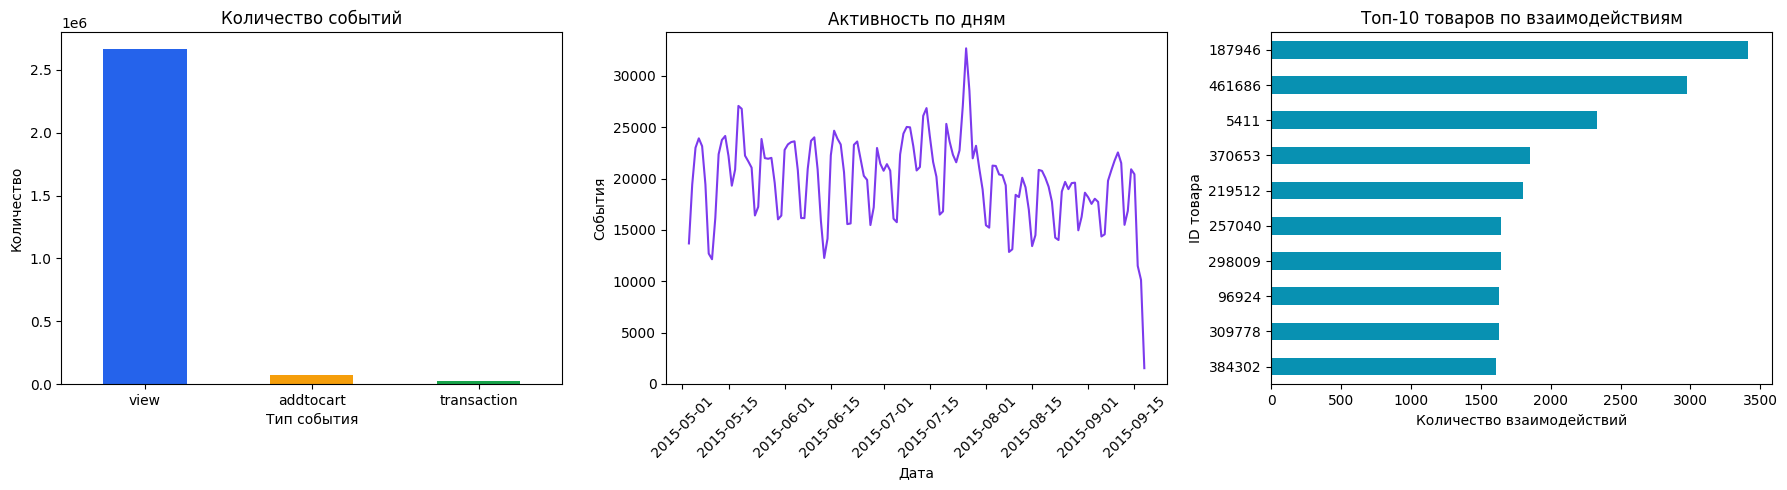

In [3]:

# Краткая сводка по событиям
eda_events = events_log.copy()
eda_events['event_datetime'] = pd.to_datetime(eda_events['timestamp'], unit='ms')
eda_events['date'] = eda_events['event_datetime'].dt.date

print(f'Размер датасета: {eda_events.shape[0]:,} строк, {eda_events.shape[1] - 2} исходных признака')
print(f'Период: {eda_events["event_datetime"].min():%Y-%m-%d} — {eda_events["event_datetime"].max():%Y-%m-%d}')
print(f'Уникальные пользователи: {eda_events["visitorid"].nunique():,}')
print(f'Уникальные товары: {eda_events["itemid"].nunique():,}')
print(f'Пропуски transactionid: {eda_events["transactionid"].isna().mean():.1%}')
print('\nРаспределение событий:')
display(eda_events['event'].value_counts().to_frame('count'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Типы взаимодействий
eda_events['event'].value_counts().plot.bar(ax=axes[0], color=['#2563eb', '#f59e0b', '#16a34a'])
axes[0].set_title('Количество событий')
axes[0].set_xlabel('Тип события')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

# Динамика активности по дням
eda_events.groupby('date').size().plot(ax=axes[1], color='#7c3aed')
axes[1].set_title('Активность по дням')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('События')
axes[1].tick_params(axis='x', rotation=45)

# Топ товаров по числу взаимодействий
eda_events['itemid'].value_counts().head(10).sort_values().plot.barh(ax=axes[2], color='#0891b2')
axes[2].set_title('Топ-10 товаров по взаимодействиям')
axes[2].set_xlabel('Количество взаимодействий')
axes[2].set_ylabel('ID товара')

plt.tight_layout()
plt.show()

### Проверим и подгрузим **Category Tree**

In [4]:
category_tree = pd.read_csv('data_import/category_tree.csv')
display(category_tree.head(3))
display(category_tree.info())
display(category_tree.describe())
display(category_tree.isna().sum())

print('Total Duplicates detected: {}'.format(category_tree[category_tree.duplicated()].shape[0]))
# Delete duplicates:
category_tree = category_tree.drop_duplicates()
print('Table size after delete duplicates: {}'.format(category_tree.shape))

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


None

,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000


categoryid     0
parentid      25
dtype: int64

Total Duplicates detected: 0
Table size after delete duplicates: (1669, 2)


### EDA

Размер дерева: 1,669 категорий
Уникальные категории: 1,669
Пропуски в родительской категории: 25
Корневые категории: 25
Максимальное число дочерних категорий: 31

Первые строки:


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


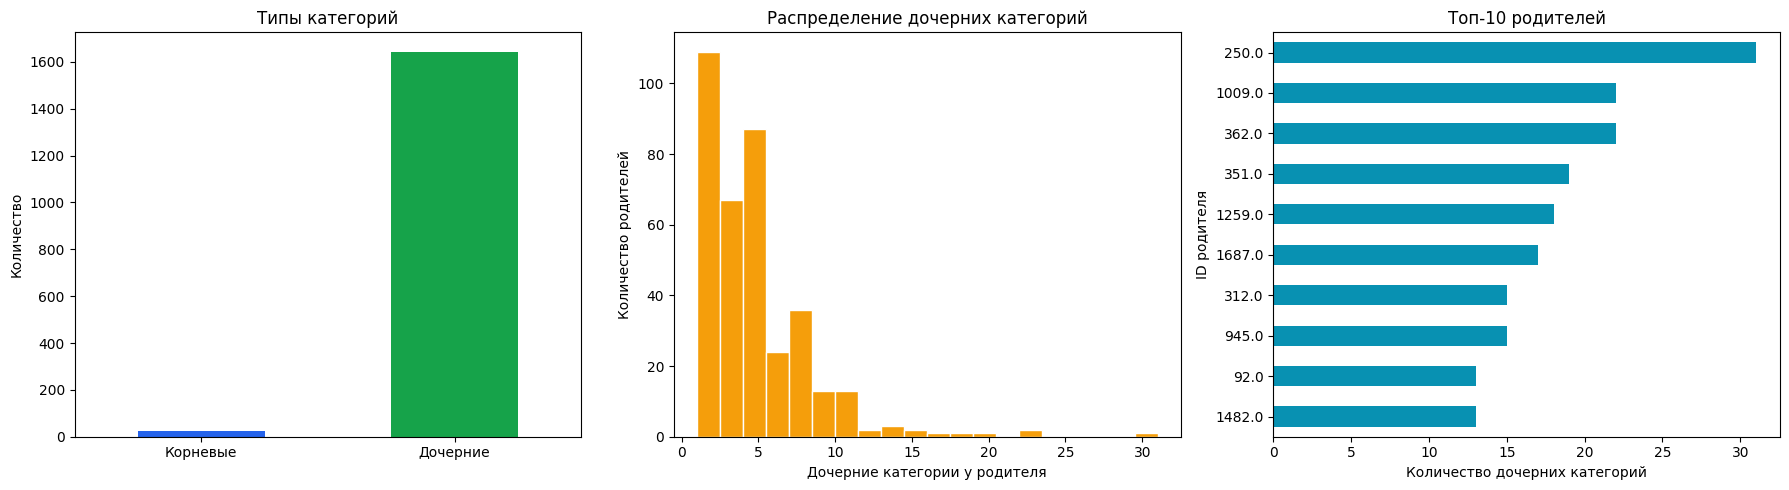

In [5]:
# Краткая сводка по дереву категорий
eda_categories = category_tree.copy()
category_col = next(col for col in ('categoryid', 'category_id') if col in eda_categories.columns)
parent_col = next(col for col in ('parentid', 'parent_id') if col in eda_categories.columns)

root_categories = eda_categories[parent_col].isna().sum()
children_by_parent = eda_categories[parent_col].dropna().value_counts()

print(f'Размер дерева: {eda_categories.shape[0]:,} категорий')
print(f'Уникальные категории: {eda_categories[category_col].nunique():,}')
print(f'Пропуски в родительской категории: {eda_categories[parent_col].isna().sum():,}')
print(f'Корневые категории: {root_categories:,}')
print(f'Максимальное число дочерних категорий: {children_by_parent.max():,}')
print('\nПервые строки:')
display(eda_categories.head())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Корневые и дочерние категории
pd.Series(
    {'Корневые': root_categories, 'Дочерние': len(eda_categories) - root_categories}
).plot.bar(ax=axes[0], color=['#2563eb', '#16a34a'])
axes[0].set_title('Типы категорий')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

# Распределение количества дочерних категорий у родителей
children_by_parent.plot.hist(ax=axes[1], bins=20, color='#f59e0b', edgecolor='white')
axes[1].set_title('Распределение дочерних категорий')
axes[1].set_xlabel('Дочерние категории у родителя')
axes[1].set_ylabel('Количество родителей')

# Топ родителей по числу дочерних категорий
top_parents = children_by_parent.head(10).sort_values()
top_parents.index = top_parents.index.astype(str)
top_parents.plot.barh(ax=axes[2], color='#0891b2')
axes[2].set_title('Топ-10 родителей')
axes[2].set_xlabel('Количество дочерних категорий')
axes[2].set_ylabel('ID родителя')

plt.tight_layout()
plt.show()

### Проверим и подгрузим **item_properties_part1**

In [6]:
item_properties_part1 = pd.read_csv('data_import/item_properties_part1.csv')
display(item_properties_part1.head(3))
display(item_properties_part1.info())
display(item_properties_part1.describe())
display(item_properties_part1.isna().sum())

print('Total Duplicates detected: {}'.format(item_properties_part1[item_properties_part1.duplicated()].shape[0]))
# Delete duplicates:
item_properties_part1 = item_properties_part1.drop_duplicates()
print('Table size after delete duplicates: {}'.format(item_properties_part1.shape))

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 335.7+ MB


None

,timestamp,itemid
count,1.100000e+07,1.100000e+07
mean,1.435158e+12,2.333851e+05
std,3.327653e+09,1.348258e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165150e+05
50%,1.433646e+12,2.334990e+05
75%,1.437880e+12,3.501860e+05
max,1.442113e+12,4.668660e+05


timestamp    0
itemid       0
property     0
value        0
dtype: int64

Total Duplicates detected: 0
Table size after delete duplicates: (10999999, 4)


### Проверим и подгрузим **item_properties_part2**

In [7]:
item_properties_part2 = pd.read_csv('data_import/item_properties_part2.csv')
display(item_properties_part2.head(3))
display(item_properties_part2.info())
display(item_properties_part2.describe())
display(item_properties_part2.isna().sum())

print('Total Duplicates detected: {}'.format(item_properties_part2[item_properties_part2.duplicated()].shape[0]))
# Delete duplicates:
item_properties_part2 = item_properties_part2.drop_duplicates()
print('Table size after delete duplicates: {}'.format(item_properties_part2.shape))

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275903 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 283.1+ MB


None

,timestamp,itemid
count,9.275903e+06,9.275903e+06
mean,1.435156e+12,2.333968e+05
std,3.327970e+09,1.348682e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165175e+05
50%,1.433646e+12,2.334620e+05
75%,1.437880e+12,3.504470e+05
max,1.442113e+12,4.668660e+05


timestamp    0
itemid       0
property     0
value        0
dtype: int64

Total Duplicates detected: 0
Table size after delete duplicates: (9275903, 4)


### EDA

Общий размер: 20,275,902 строк
Уникальные товары: 417,053
Уникальные свойства: 1,104
Уникальные значения свойств: 1,966,868
Дубликаты: 0

Пропуски:


,count
timestamp,0
itemid,0
property,0
value,0


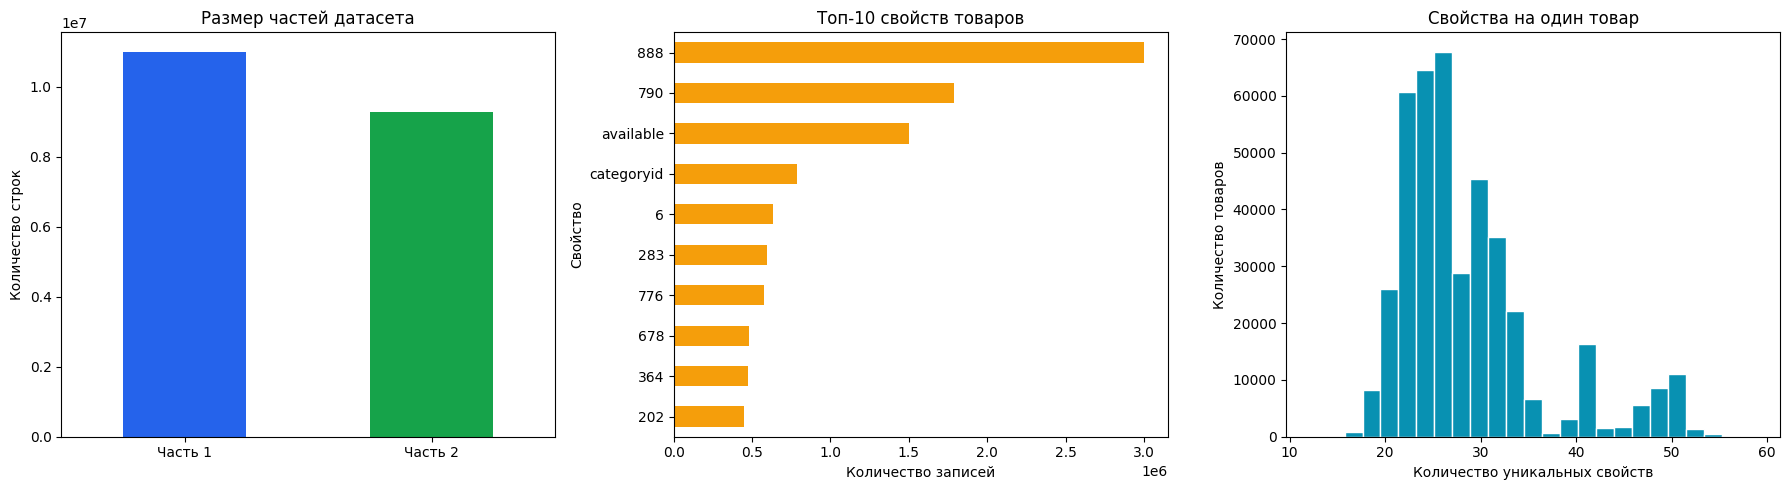

In [8]:
# Краткая сводка по свойствам товаров
properties_part1 = item_properties_part1.copy()
properties_part2 = item_properties_part2.copy()
item_properties_eda = pd.concat(
    [properties_part1, properties_part2],
    ignore_index=True
)
item_col = next(col for col in ('itemid', 'item_id') if col in item_properties_eda.columns)

print(f'Общий размер: {item_properties_eda.shape[0]:,} строк')
print(f'Уникальные товары: {item_properties_eda[item_col].nunique():,}')
print(f'Уникальные свойства: {item_properties_eda["property"].nunique():,}')
print(f'Уникальные значения свойств: {item_properties_eda["value"].nunique():,}')
print(f'Дубликаты: {item_properties_eda.duplicated().sum():,}')
print('\nПропуски:')
display(item_properties_eda.isna().sum().to_frame('count'))

properties_per_item = item_properties_eda.groupby(item_col)['property'].nunique()
top_properties = item_properties_eda['property'].value_counts().head(10).sort_values()
part_sizes = pd.Series({
    'Часть 1': len(properties_part1),
    'Часть 2': len(properties_part2)
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Объём частей датасета
part_sizes.plot.bar(ax=axes[0], color=['#2563eb', '#16a34a'])
axes[0].set_title('Размер частей датасета')
axes[0].set_ylabel('Количество строк')
axes[0].tick_params(axis='x', rotation=0)

# Самые часто встречающиеся свойства
top_properties.plot.barh(ax=axes[1], color='#f59e0b')
axes[1].set_title('Топ-10 свойств товаров')
axes[1].set_xlabel('Количество записей')
axes[1].set_ylabel('Свойство')

# Покрытие товаров свойствами
properties_per_item.plot.hist(ax=axes[2], bins=25, color='#0891b2', edgecolor='white')
axes[2].set_title('Свойства на один товар')
axes[2].set_xlabel('Количество уникальных свойств')
axes[2].set_ylabel('Количество товаров')

plt.tight_layout()
plt.show()

### Задание 2.3

Сколько уникальных признаков товара есть в датасете? Ответ вводите без пробелов и знаков препинания.

In [9]:
item_properties = pd.concat(
    [item_properties_part1, item_properties_part2],
    ignore_index=True
)

unique_properties = item_properties['property'].nunique()
print(unique_properties)

1104


— Так, я тоже посмотрела на данные! Что у нас есть в наличии:

**events — датасет с событиями. Колонки:**

    - timestamp — время события
    - visitorid — идентификатор пользователя
    - event — тип события
    - itemid — идентификатор объекта
    - transactionid — идентификатор транзакции, если она проходила

**category_tree — файл с деревом категорий (можно восстановить дерево).**

    - category_id — идентификатор категорий
    - parent_id — идентификатор родительской категории

**item_properties — файл с свойствами товаров.**

    - timestamp — момент записи значения свойства
    - item_id — идентификатор объекта
    - property — свойство, кажется, они все, кроме категории, захешированы
    - value — значение свойства


### Задание 2.4

Анастасия: Кстати, слушай… Это, конечно, не моё дело, но мы же не можем оптимизировать оборот? Как думаешь, как мы будем измерять качество рекомендаций? У нас вроде только три места для показа товаров на главной странице. А ведь клиента интересует только продажи!
 
Ответ: Precision@3


# 3. Декомпозиция на четыре этапа и задача текущего спринта

 	

Тимофей: Вижу, что ты слегка погрузился в задачу и в данные. Можешь прикинуть, что ты будешь делать дальше? Как разбить задачи? Давай ты сделаешь такую табличку на следующие три недели:

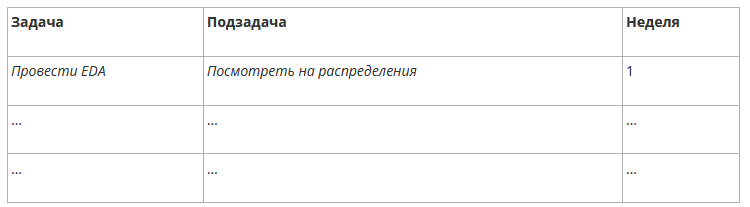

— Мне важно, чтобы к концу недели у тебя был план. Вот каких результатов я от тебя жду:

    Создан сервис, выдающий рекомендации по идентификатору пользователя.
    Сервис обёрнут в Docker.
    У сервиса есть понятная документация, описание функциональности.
    Сделана презентация для менеджера с описанием принципов работы.

Не переживай, если не уверен в разбиении задач, мы с тобой по нему чуть позже пройдёмся. Пожалуйста, самостоятельно заполни эту табличку до конца недели — отметь, на какие таски и подзадачи ты видишь разделение проекта.

| Неделя | Что делать | Что должно быть в результате |
|---|---|---|
| 1 | EDA и подготовка данных: изучить датасет, понять структуру пользователей, товаров и взаимодействий; проверить пропуски, дубликаты, выбросы; посмотреть распределения оценок/покупок/просмотров; выявить явные и скрытые паттерны; сформировать train/validation split; выбрать метрики качества (`Precision@K`, `Recall@K`, `MAP`, `NDCG`, `MRR`); определить тип рекомендательной системы (collaborative / content-based / hybrid). | Готовый разведочный анализ данных, список гипотез, чистый датасет, описанные метрики, базовый план моделирования. |
| 2 | Базовая модель: подготовить матрицу взаимодействий, построить baseline-модели (popular items, item-based CF, user-based CF, matrix factorization/ALS, если подходит данные); сделать валидацию и сравнить результаты; оценить качество; выявить слабые места модели; понять, как обрабатывать cold start и длинный хвост товаров. | Рабочий baseline-рекомендатель, сравнение моделей по метрикам, анализ ошибок и выбор лучшей базовой модели для дальнейшего улучшения. |
| 3 | Улучшение и финализация: добавить признаки пользователей/товаров, попробовать hybrid-решение, fine-tune гиперпараметров, проверить качество на валидации и на holdout-сете, добавить фильтрацию по бизнес-логике (например, исключение уже купленного), подготовить демонстрацию рекомендаций; сделать финальный вывод по качеству модели и оформить проект. | Готовая рекомендательная система в ноутбуке/скрипте, сравнительный отчёт по метрикам, визуализация рекомендаций, финальная презентация/README проекта. |
| Итог | Завершить MVP проекта: от данных до рабочей модели и оценки качества. К концу проекта должен быть понятный pipeline — «данные → EDA → baseline → улучшение → финальная рекомендательная система → выводы». | Готовый проект с аналитической частью, моделью рекомендаций и результатами оценки качества. |

# 4. Дополнительная задача от продакт-менеджера

Мария: О, ты на месте? Отлично! А то смотрю — всего 20:00, пятница, а все уже куда-то делись… Можешь, пожалуйста, прикинуть быстренько? Если мы всем будем рекомендовать топовые товары (по числу транзакций), то какое качество рекомендаций получится?

Короче, давай посчитаем такую штуку: возьмём статистику до 1 июля включительно и потом прикинем, как эти товары покупались после 1 июля. Мне нужно узнать, сколько процентов покупок мы можем так покрыть. Сделаешь быстренько? А то меня уже такси ждёт…

Потом мне напишешь письмом результат, я прочту.

### Задание 4.1

Какой процент продаж обеспечивают топовые товары (точка отсечения — 1 июля)? Для расчёта используйте топ-3 товаров по числу транзакций.

Ответ введите без знака процента. 

In [10]:
events_with_datetime = events_log.copy()
events_with_datetime['event_datetime'] = pd.to_datetime(
    events_with_datetime['timestamp'],
    unit='ms'
)

# Берём транзакции до 1 июля включительно
cutoff_date = pd.Timestamp('2015-07-02')
sales_until_july = events_with_datetime[
    (events_with_datetime['event_datetime'] < cutoff_date)
    & events_with_datetime['transactionid'].notna()
]

transactions_by_item = (
    sales_until_july.groupby('itemid')['transactionid']
    .nunique()
    .sort_values(ascending=False)
    .rename('transactions')
    .reset_index()
)
top_3_items = transactions_by_item.head(3)
top_3_item_ids = top_3_items['itemid'].tolist()

sales_top_3_count = sales_until_july[
    sales_until_july['itemid'].isin(top_3_item_ids)
]['transactionid'].nunique()
total_sales_count = sales_until_july['transactionid'].nunique()
share_of_top_3 = sales_top_3_count / total_sales_count * 100

print(f'Период расчёта: до 1 июля 2015 включительно')
print(f'Топ-3 товаров: {top_3_item_ids}')
print(f'Транзакции топ-3: {sales_top_3_count:,}')
print(f'Все транзакции: {total_sales_count:,}')
print(f'Доля продаж топ-3: {share_of_top_3:.2f}%')

Период расчёта: до 1 июля 2015 включительно
Топ-3 товаров: [119736, 369447, 7943]
Транзакции топ-3: 97
Все транзакции: 7,893
Доля продаж топ-3: 1.23%


# 5. Итоги недели

Что ж, вас можно поздравить с завершением первой рабочей недели!

Что важного удалось сделать за это время:

✔️ перевести бизнес-задачу в прикладную плоскость и выбрать подходящую метрику;

✔️ разобраться, какие данные есть в наличии;

✔️ декомпозировать задачу на несколько спринтов;

✔️ оперативно решить неожиданный запрос от продакта.

Далее мы будем поэтапно решать поставленные задачи и в конце концов подготовим отчёт, который устроит бизнес-заказчика.

# Дипломный проект - Неделя 2

## 0. Разбор решения первой недели

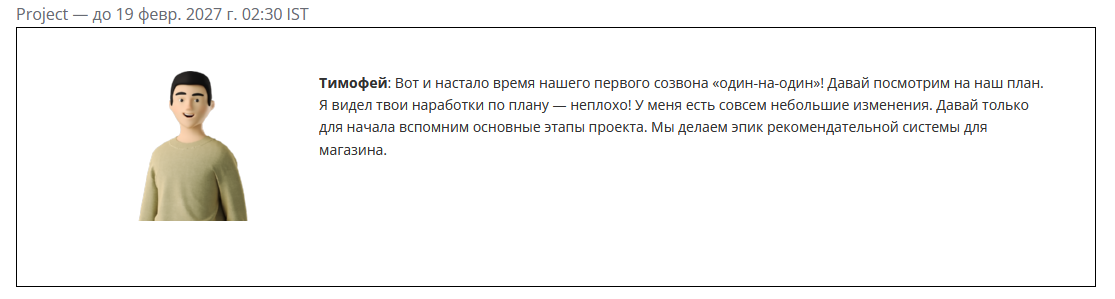

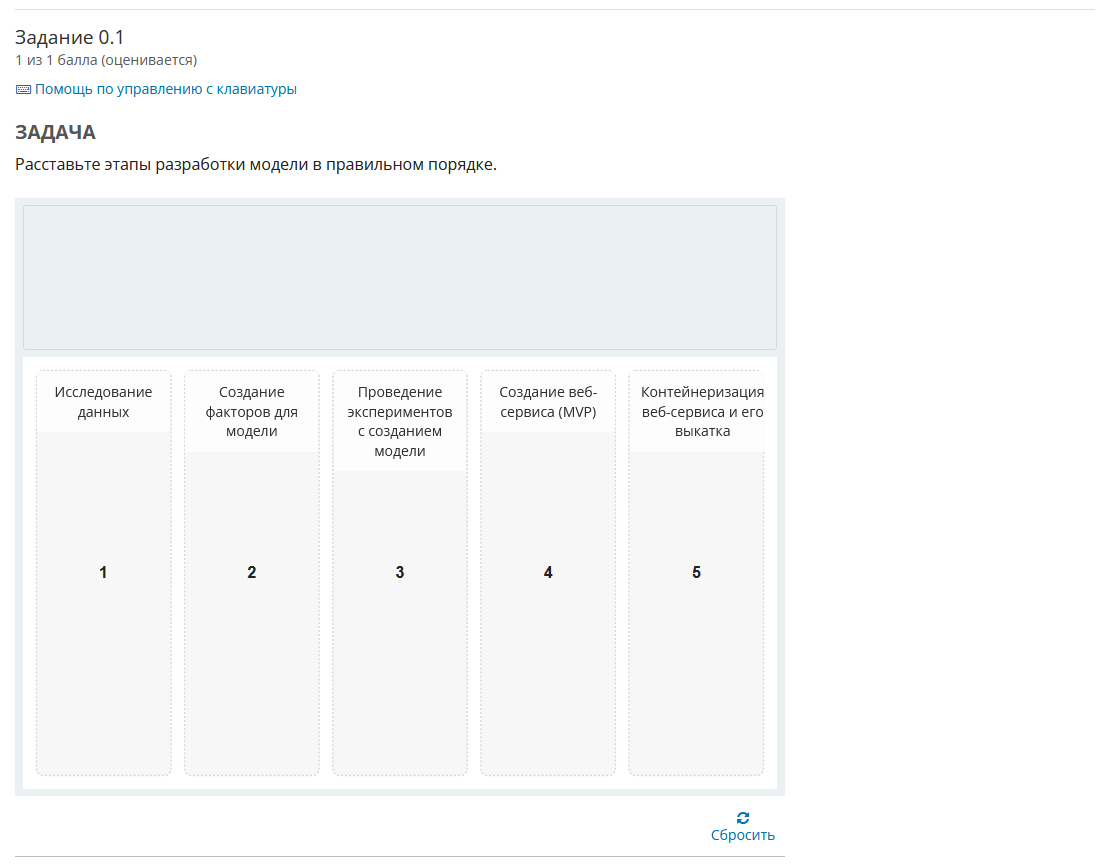

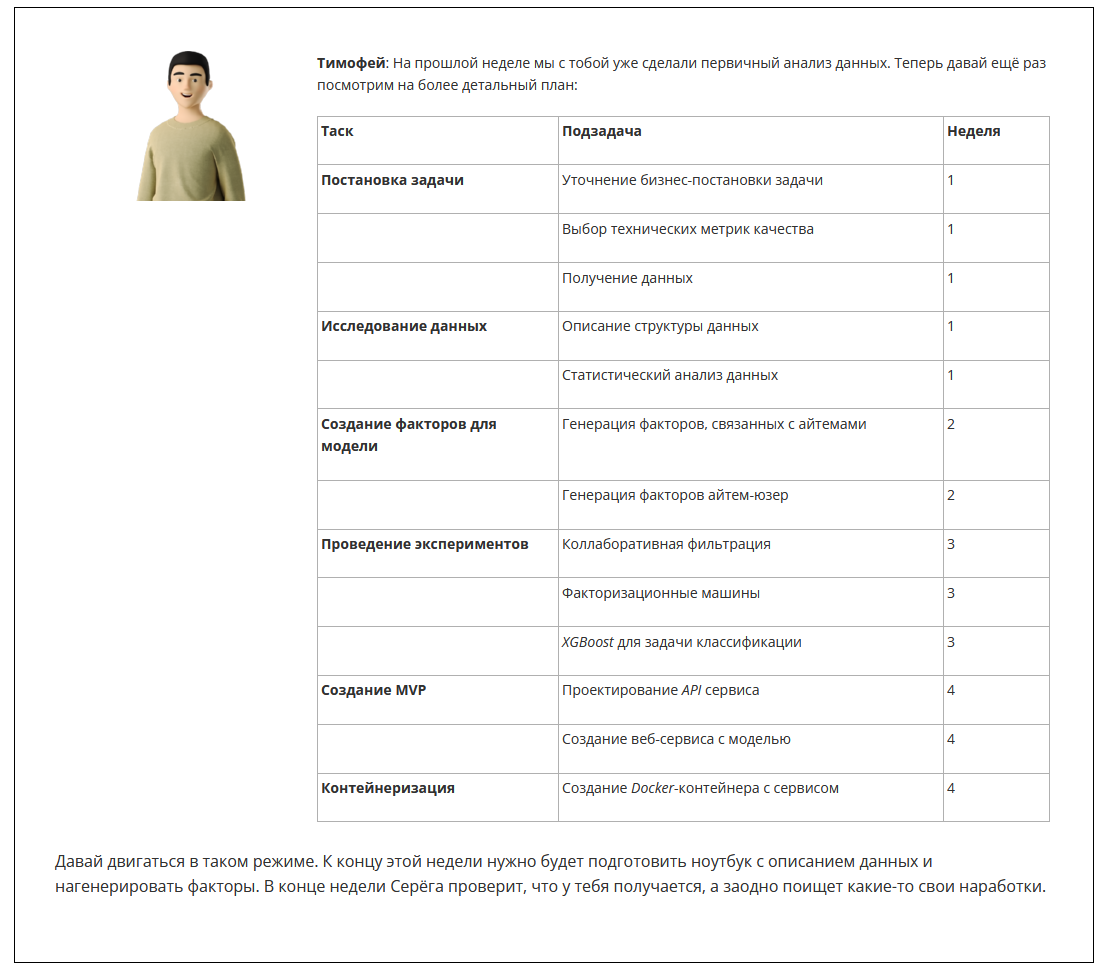

## 1. Дополнительная задача от старшего ML-инженера

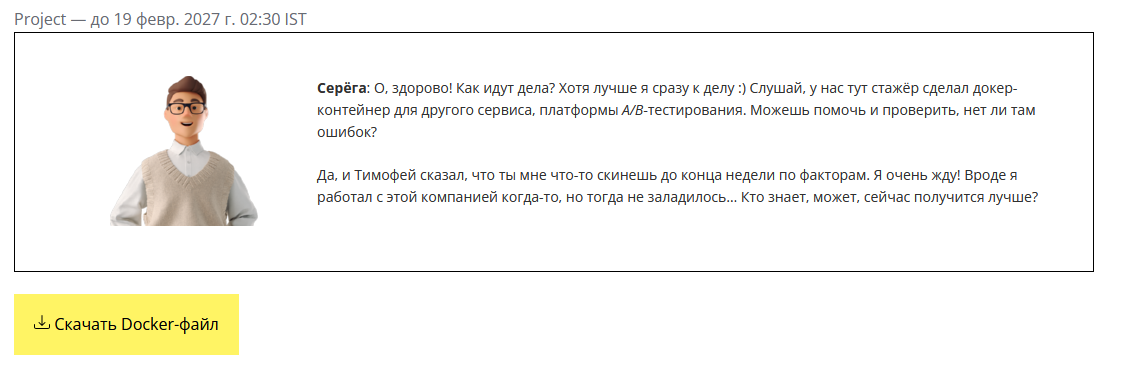

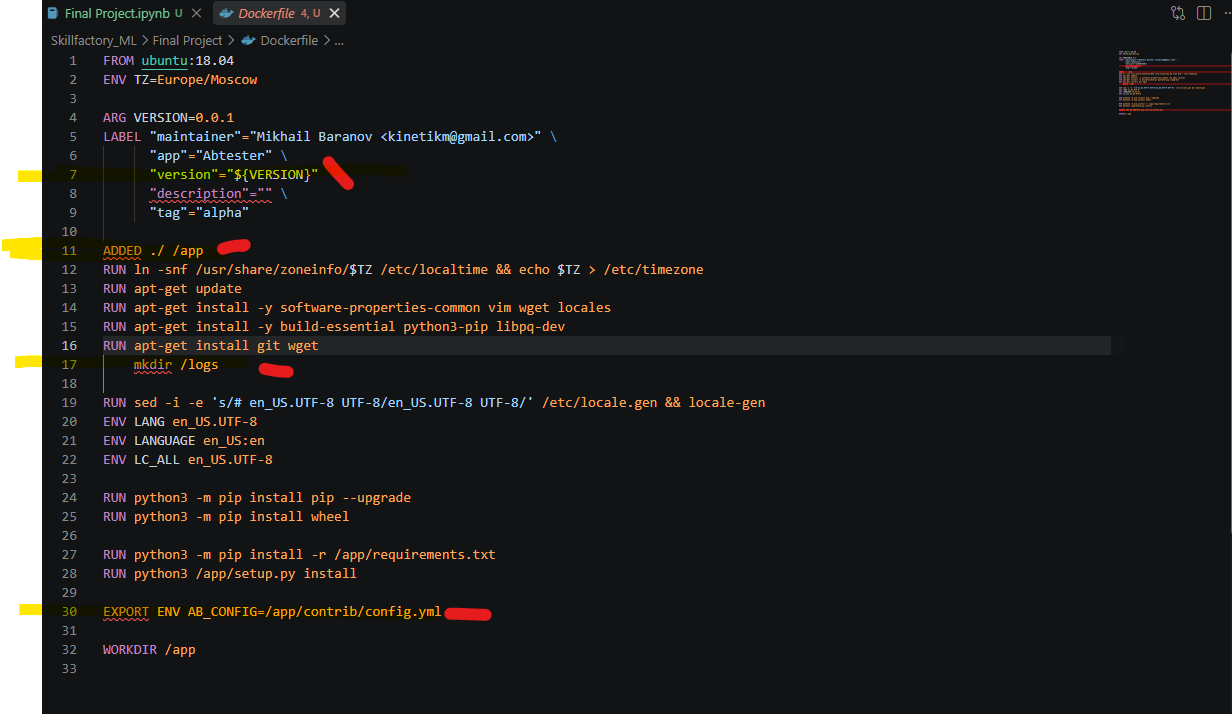

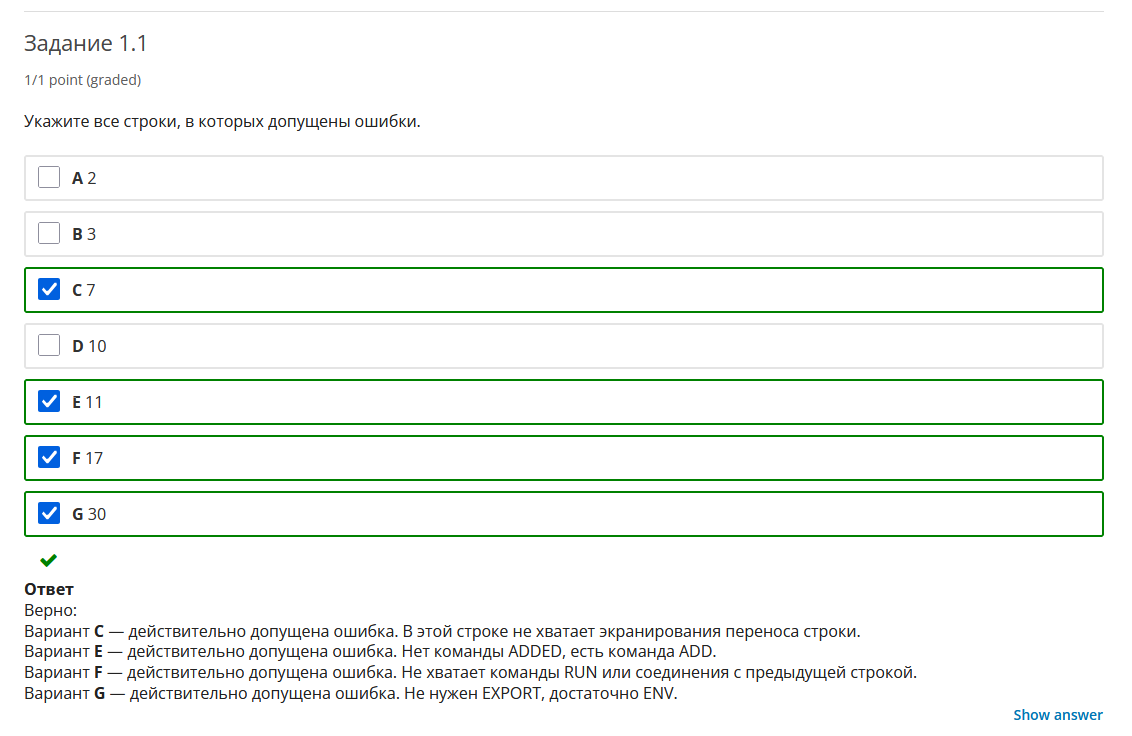

## 2. Итоги недели

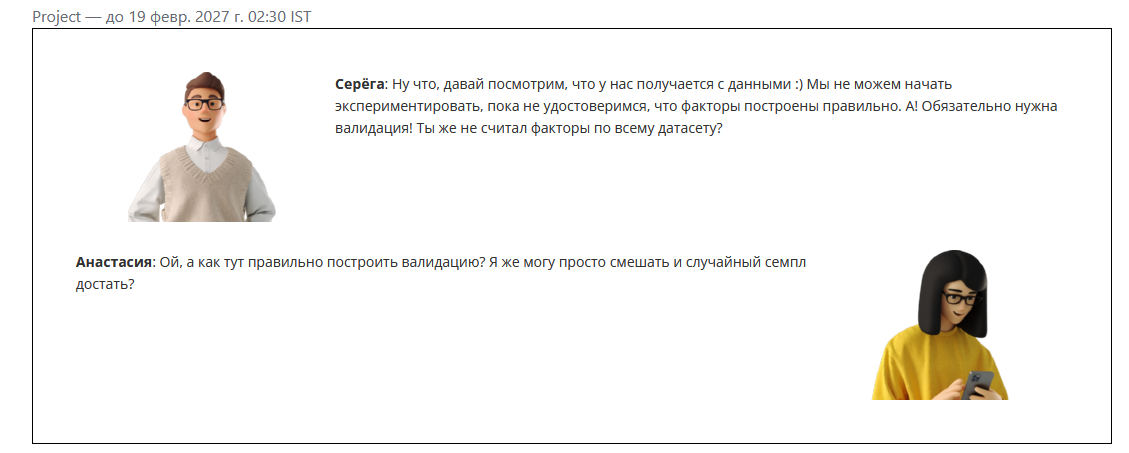

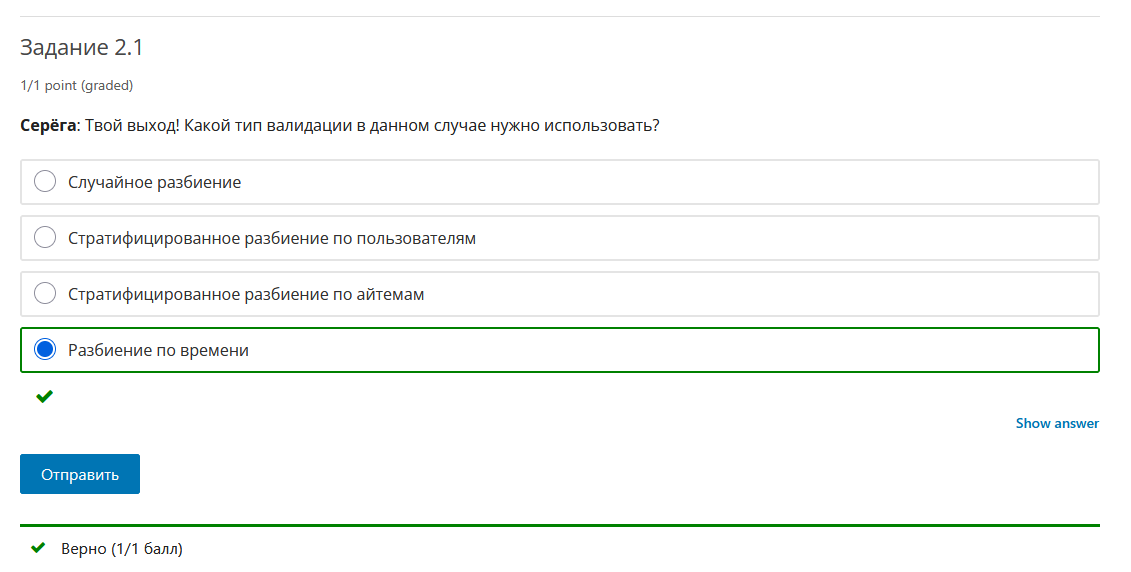